# 1. Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 2. Load Clean Dataset

In [32]:
df = pd.read_csv("Airline_Delay_data.csv")

print(df)

        year  month carrier          carrier_name airport  \
0       2025      1      G4         Allegiant Air     ELM   
1       2025      1      G4         Allegiant Air     ELP   
2       2025      1      G4         Allegiant Air     EUG   
3       2025      1      G4         Allegiant Air     EVV   
4       2025      1      G4         Allegiant Air     EWR   
...      ...    ...     ...                   ...     ...   
398228  2003      6      DL  Delta Air Lines Inc.     SEA   
398229  2003      6      DL  Delta Air Lines Inc.     SFO   
398230  2003      6      DL  Delta Air Lines Inc.     SJC   
398231  2003      6      DL  Delta Air Lines Inc.     SJU   
398232  2003      6      DL  Delta Air Lines Inc.     SLC   

                                             airport_name  arr_flights  \
0             Elmira/Corning, NY: Elmira/Corning Regional         30.0   
1                      El Paso, TX: El Paso International          2.0   
2                          Eugene, OR: Mahlon

In [49]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_rate
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30.0,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2.0,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28.0,8.0,3.74,0.0,...,2.66,2.0,0.0,409.0,236.0,0.0,70.0,0.0,103.0,0.285714
3,2025,1,G4,Allegiant Air,EVV,"Evansville, IN: Evansville Regional",18.0,1.0,0.00,1.0,...,0.00,0.0,0.0,1075.0,0.0,1075.0,0.0,0.0,0.0,0.055556
4,2025,1,G4,Allegiant Air,EWR,"Newark, NJ: Newark Liberty International",31.0,5.0,2.17,0.0,...,0.00,1.0,0.0,446.0,336.0,0.0,110.0,0.0,0.0,0.161290


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398233 entries, 0 to 398232
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 398233 non-null  int64  
 1   month                398233 non-null  int64  
 2   carrier              398233 non-null  object 
 3   carrier_name         398233 non-null  object 
 4   airport              398233 non-null  object 
 5   airport_name         398233 non-null  object 
 6   arr_flights          398233 non-null  float64
 7   arr_del15            398233 non-null  float64
 8   carrier_ct           398233 non-null  float64
 9   weather_ct           398233 non-null  float64
 10  nas_ct               398233 non-null  float64
 11  security_ct          398233 non-null  float64
 12  late_aircraft_ct     398233 non-null  float64
 13  arr_cancelled        398233 non-null  float64
 14  arr_diverted         398233 non-null  float64
 15  arr_delay        

In [58]:
df.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_rate
count,398233.000000,398233.000000,398233.000000,398233.000000,398233.000000,398233.000000,398233.000000,398233.000000,398233.000000,398233.000000,398233.000000,398233.000000,398233.000000,398233.000000,398233.00000,398233.000000,398233.000000,397576.000000
mean,2014.421344,6.524078,361.066868,69.427928,20.506444,2.504093,22.172888,0.172345,24.072192,6.778122,0.832791,4160.603945,1307.157081,222.962615,1024.31918,7.132551,1599.025249,0.197867
std,6.474505,3.463111,993.235611,193.407552,48.281534,9.563484,79.412584,0.825596,74.359751,35.058237,3.789910,12746.578919,3822.197176,883.017772,4332.41131,39.098359,5150.741710,0.114688
min,2003.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.00000,0.000000,0.000000,0.000000
25%,2009.000000,4.000000,55.000000,8.000000,2.760000,0.000000,1.380000,0.000000,1.500000,0.000000,0.000000,402.000000,133.000000,0.000000,48.00000,0.000000,75.000000,0.121831
50%,2015.000000,7.000000,112.000000,21.000000,7.490000,0.500000,4.890000,0.000000,5.470000,1.000000,0.000000,1136.000000,409.000000,22.000000,182.00000,0.000000,340.000000,0.184874
75%,2020.000000,10.000000,254.000000,52.000000,18.610000,2.000000,13.960000,0.000000,16.110000,4.000000,1.000000,2968.000000,1073.000000,155.000000,554.00000,0.000000,1086.000000,0.258065
max,2025.000000,12.000000,21977.000000,6377.000000,1886.580000,717.940000,4091.270000,80.560000,2588.130000,4951.000000,256.000000,648300.000000,321792.000000,64550.000000,238440.00000,3760.000000,279153.000000,1.000000


# Checking Missing Values

In [33]:
df.isnull().sum()

,0
year,0
month,0
carrier,0
carrier_name,0
airport,0
airport_name,0
arr_flights,657
arr_del15,950
carrier_ct,657
weather_ct,657


In [34]:
df.fillna(0, inplace=True)

In [35]:
# Remove Text Columns

df_clean = df.drop(columns=['carrier_name','airport_name'])

In [38]:
# Create delay rate

df["delay_rate"] = df["arr_del15"] / df["arr_flights"]

In [59]:
# Airline and airport names must be encoded.\

le = LabelEncoder()

df["carrier"] = le.fit_transform(df["carrier"])
df["airport"] = le.fit_transform(df["airport"])

In [61]:
# Save Clean Dataset

df_clean.to_csv("clean_airline_delay_dataset.csv", index=False)

# Exploratory Data Analysis

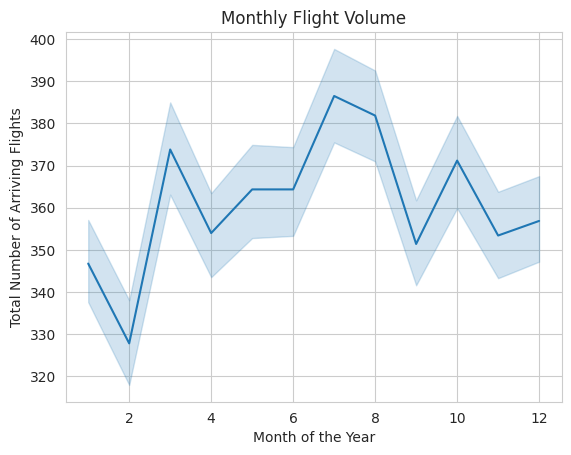

In [69]:
# 1. Monthly Flight Volume
sns.lineplot(x="month", y="arr_flights", data=df)
plt.title("Monthly Flight Volume")
plt.xlabel("Month of the Year")
plt.ylabel("Total Number of Arriving Flights")
plt.show()

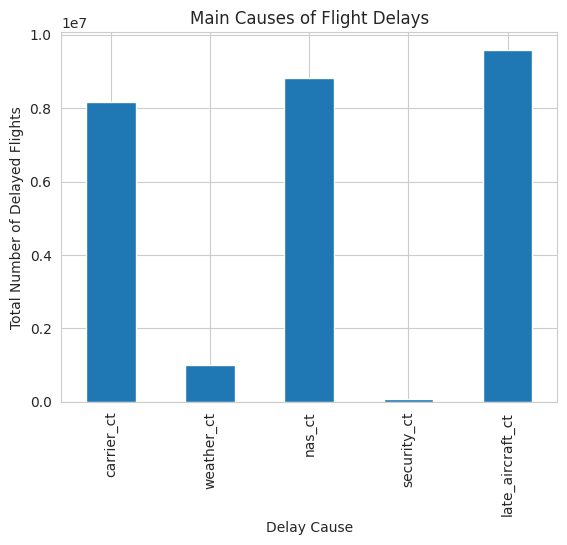

In [70]:
# 2. Main Causes of Flight Delays

delay_cols = ["carrier_ct","weather_ct","nas_ct","security_ct","late_aircraft_ct"]

df[delay_cols].sum().plot(kind="bar")
plt.title("Main Causes of Flight Delays")
plt.xlabel("Delay Cause")
plt.ylabel("Total Number of Delayed Flights")
plt.show()

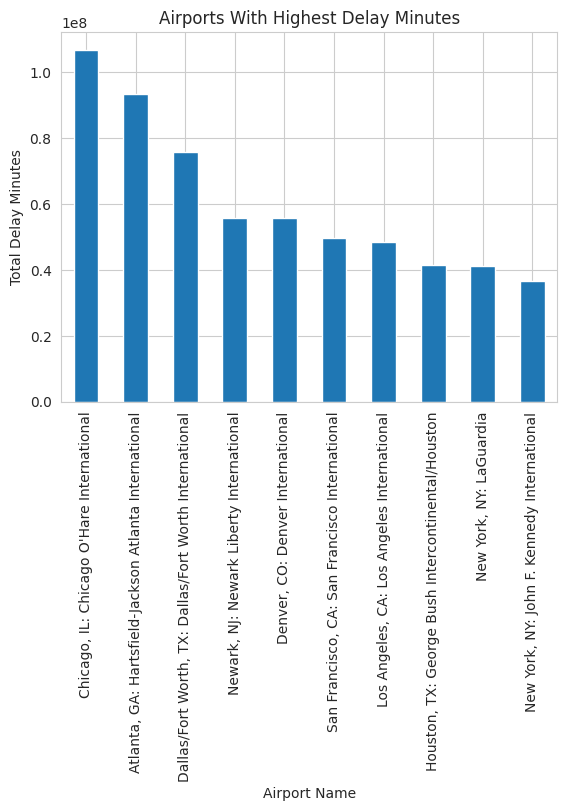

In [71]:
# 3. Airports With Highest Total Delay Minutes

top_airports = df.groupby("airport_name")["arr_delay"].sum().sort_values(ascending=False).head(10)

top_airports.plot(kind="bar")
plt.title("Airports With Highest Delay Minutes")
plt.xlabel("Airport Name")
plt.ylabel("Total Delay Minutes")
plt.show()

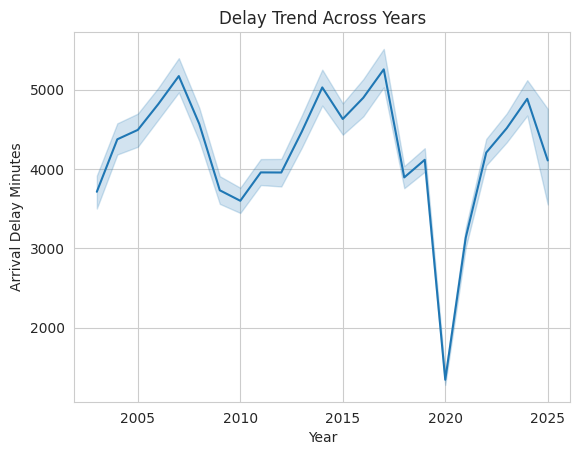

In [73]:
# 4. Delay Trend Over Time

sns.lineplot(x="year", y="arr_delay", data=df)
plt.title("Delay Trend Across Years")
plt.xlabel("Year")
plt.ylabel("Arrival Delay Minutes")
plt.show()

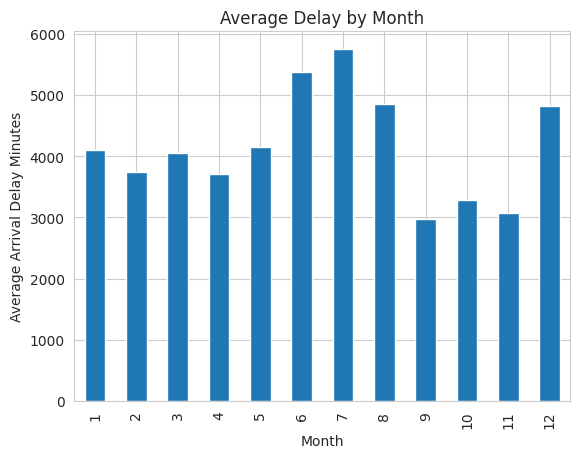

In [74]:
# 5. Monthly Delay Pattern

df.groupby("month")["arr_delay"].mean().plot(kind="bar")
plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay Minutes")
plt.show()

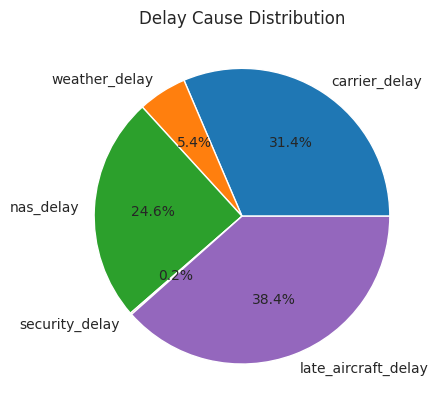

In [76]:
# 4. Delay Cause Contribution

delay_causes.plot(kind="pie", autopct='%1.1f%%')
plt.title("Delay Cause Distribution")
plt.show()

# Root Cause Analysis

<Axes: >

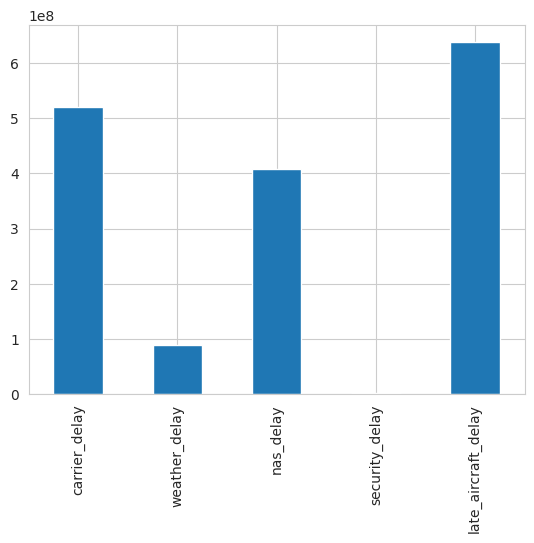

In [68]:
delay_causes = df[
["carrier_delay","weather_delay","nas_delay","security_delay","late_aircraft_delay"]
].sum()

delay_causes.plot(kind="bar")

# Machine Learning Model

In [45]:
X = df[[
"arr_flights",
"carrier_ct",
"weather_ct",
"nas_ct",
"security_ct",
"late_aircraft_ct"
]]

y = df["arr_delay"]

In [ ]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

# Train Model

In [47]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

# Predictions

In [48]:
pred = model.predict(X_test)

# Model Evaluation

In [51]:
print("MAE:", mean_absolute_error(y_test, pred))     # average prediction error
print("R2 Score:", r2_score(y_test, pred))           # model accuracy

MAE: 740.0330145709069
R2 Score: 0.9577014122645777


# Shows which factors impact delays most

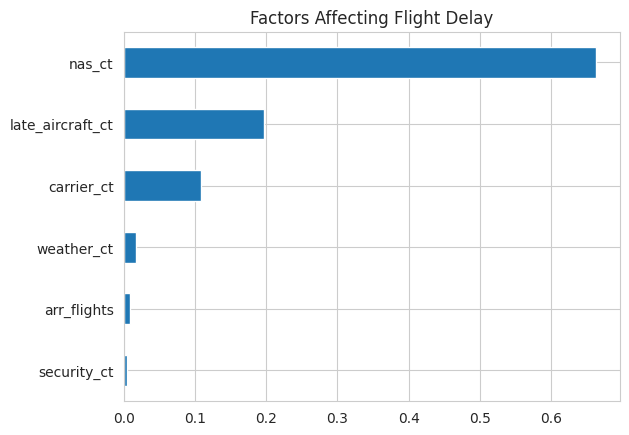

In [52]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Factors Affecting Flight Delay")
plt.show()

In [53]:
# save clean Dataset

df.to_excel("clean_airline_delay_data.xlsx", index=False)